In [23]:
#Dataset
import pandas as pd
df=pd.read_csv("../data/SMSSpamCollection",
             sep="\t",
             header=None,
             names=["label","message"]   )
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [25]:
#Dropping duplicates
df.duplicated().sum()
df=df.drop_duplicates()
df.shape

(5169, 2)

Text(0, 0.5, 'No. of Messages')

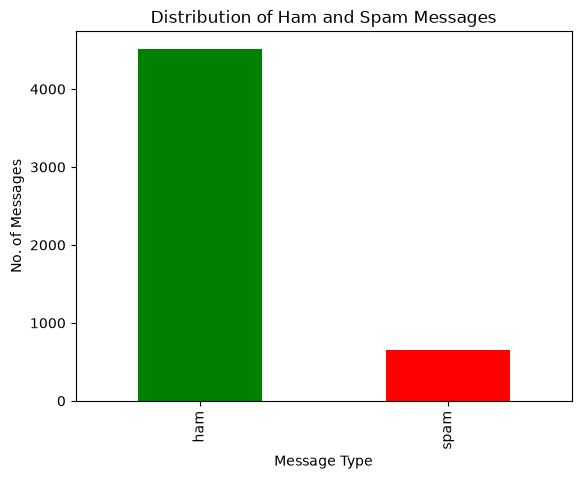

In [26]:
#Analysing the distribution of ham and spam messages in the dataset
import matplotlib.pyplot as plt
df["label"].value_counts().plot(kind="bar",color=["green","red"])
plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("No. of Messages")

In [27]:
#Feature Extraction
df["num_char"]=df["message"].apply(len)
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
df["num_sentences"]=df["message"].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

[nltk_data] Downloading package punkt to C:\Users\ANSH
[nltk_data]     YADAV\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ANSH
[nltk_data]     YADAV\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,label,message,num_char,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,2
1,ham,Ok lar... Joking wif u oni...,29,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,2
3,ham,U dun say so early hor... U c already then say...,49,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,1


In [28]:
#Data Preprocessing
import re
import nltk 
from  nltk.corpus import stopwords
nltk.download("wordnet")
nltk.download("omw-1'4")

def clean_text(text):
    text = re.sub(r'(https?://\S+|www\.\S+)',' URL ',text)
    text= str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ",text)
    
    return " ".join(text.split())
df["cleaned_message"]=df["message"].apply(clean_text)
print(repr(df["cleaned_message"].iloc[0]))
df[["message","cleaned_message"]].head()

'go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat'


[nltk_data] Downloading package wordnet to C:\Users\ANSH
[nltk_data]     YADAV\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading omw-1'4: Package "omw-1'4" not found in
[nltk_data]     index


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [29]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
def stem_text(text):
    return " ".join(stemmer.stem(word) for word in text.split() )
df["cleaned_message_no_stem"] = df["cleaned_message"] 
df["cleaned_message"]=df["cleaned_message"].apply(stem_text)
df[["message","cleaned_message"]].head()


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazi avail onli in bugi...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri in 2 a wkli comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so earli hor u c alreadi then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goe to usf he live around...


In [30]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["label_encoded"] = encoder.fit_transform(df["label"])
df[["label","label_encoded"]].head()

,label,label_encoded
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [31]:
#Splitting the training and testing data

from sklearn.model_selection import train_test_split
x= df["cleaned_message"]
y=df["label_encoded"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size= 0.20,
    random_state= 42,
    stratify=y )
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 4135
Testing samples: 1034


In [32]:
#Tfidf Vectorization- Word and Character level

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
word_tfidf = TfidfVectorizer()
x_train_word = word_tfidf.fit_transform(x_train)
x_test_word = word_tfidf.transform(x_test)

char_tfidf=TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=2)
x_train_char = char_tfidf.fit_transform(x_train)
x_test_char = char_tfidf.transform(x_test)
char_weight=2.0

x_train_tfidf=hstack([x_train_word,x_train_char.multiply(char_weight)]).tocsr()
x_test_tfidf=hstack([x_test_word,x_test_char.multiply(char_weight)]).tocsr()
print("Training",x_train_tfidf.shape)
print("Testing",x_test_tfidf.shape)


Training (4135, 57383)
Testing (1034, 57383)


In [33]:
#Training Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB
nb_model= MultinomialNB()
nb_model.fit(x_train_tfidf, y_train)
y_pred = nb_model.predict(x_test_tfidf)
print(y_pred[:100])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [34]:
#Testing Naive Bayes Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Naive Bayes Accuracy: 0.9816247582205029

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.86      0.92       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034


Confusion Matrix:
[[902   1]
 [ 18 113]]


In [35]:
#Training SVM Model

from sklearn.svm import SVC
svm_model = SVC(kernel="linear")
svm_model.fit(x_train_tfidf, y_train)
y_pred_svm = svm_model.predict(x_test_tfidf)
print(y_pred_svm[:100])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [36]:
#Testing SVM Model

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.9903288201160542

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       903
           1       0.99      0.93      0.96       131

    accuracy                           0.99      1034
   macro avg       0.99      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034


SVM Confusion Matrix:
[[902   1]
 [  9 122]]


In [37]:
#Training Logistic Regression Model

from sklearn.linear_model import LogisticRegression
lr_model= LogisticRegression(max_iter=1000)
lr_model.fit(x_train_tfidf, y_train)
y_pred_lr= lr_model.predict(x_test_tfidf)
print(y_pred_lr[:100])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [38]:
#Testing Logistic Regression Model

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9825918762088974

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       1.00      0.86      0.93       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034


Confusion Matrix:
[[903   0]
 [ 18 113]]


In [39]:
#Training Random Forest Model

from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_tfidf,y_train)
y_pred_rf=rf_model.predict(x_test_tfidf)
print(y_pred_rf[:100])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [40]:
#Testing Random Forest Model

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       1.00      0.88      0.93       131

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034


Confusion Matrix:
[[903   0]
 [ 16 115]]


                 Model  Accuracy  Precision  Recall  F1-Score
0          Naive Bayes    0.9816     0.9912  0.8626    0.9224
1                  SVM    0.9903     0.9919  0.9313    0.9606
2  Logistic Regression    0.9826     1.0000  0.8626    0.9262
3        Random Forest    0.9845     1.0000  0.8779    0.9350


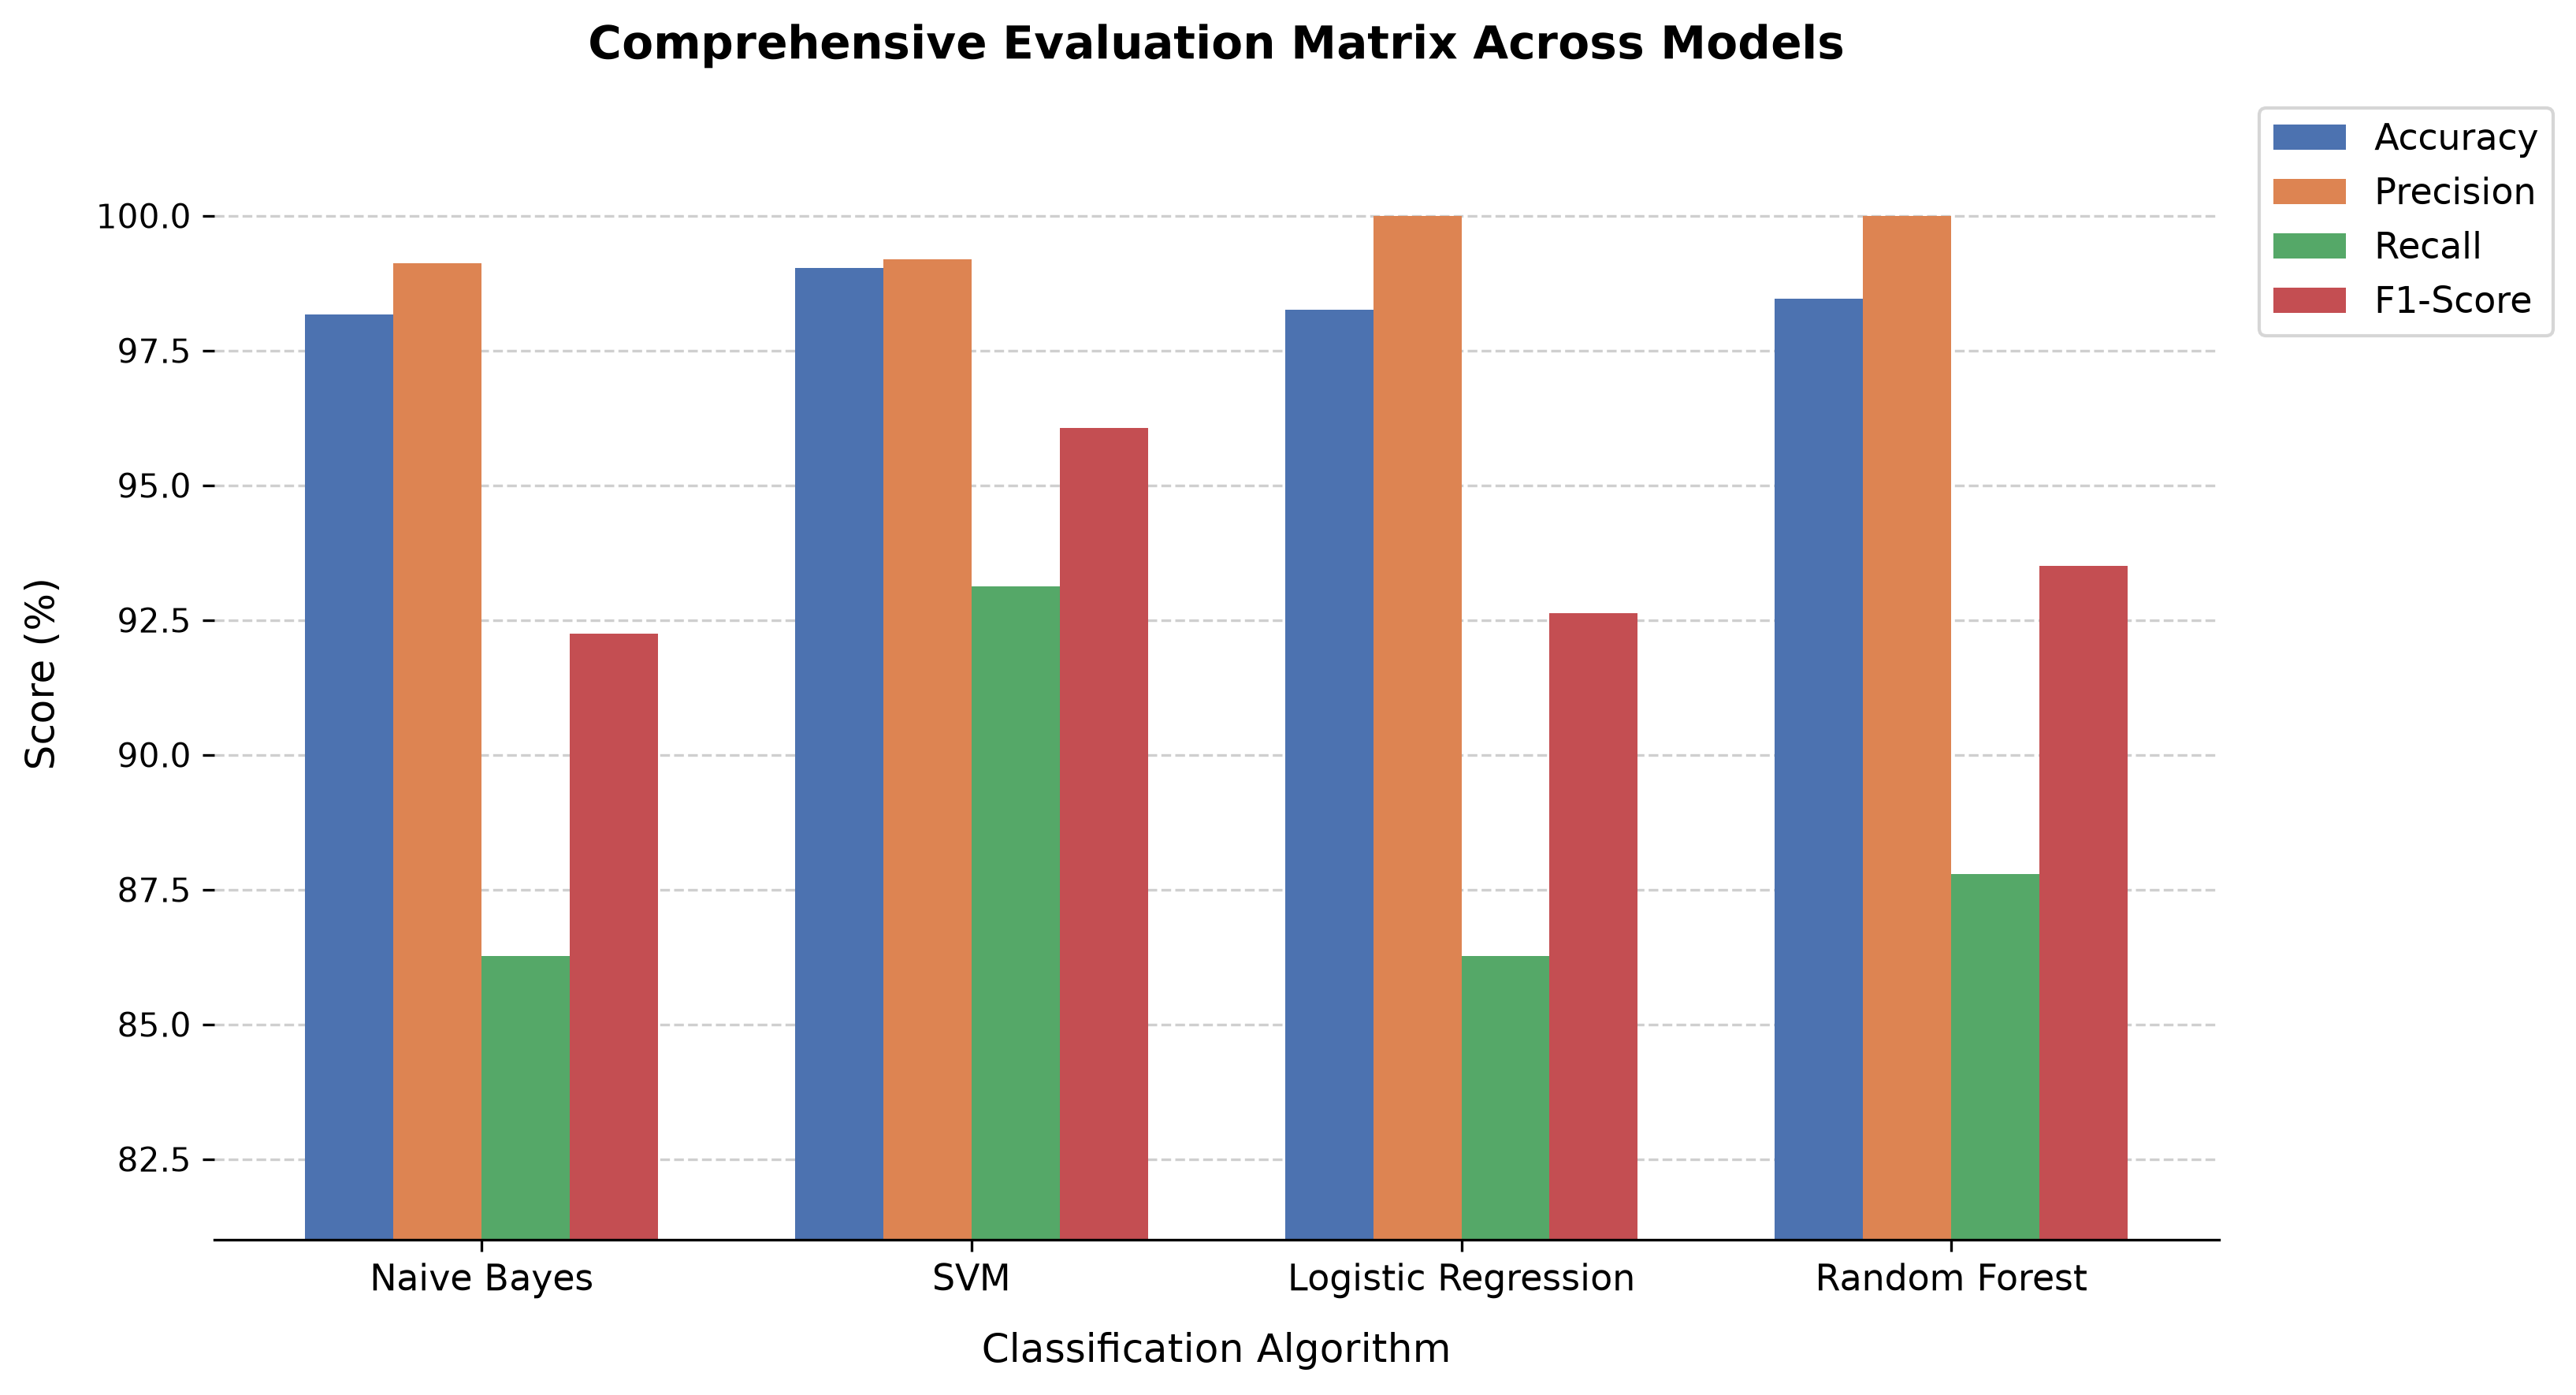

In [41]:
#Comparative Analysis of models by using dataframes and plotting graph

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = {
    "Model":["Naive Bayes","SVM","Logistic Regression","Random Forest"],
    "Accuracy":[accuracy_score(y_test,y_pred),
                accuracy_score(y_test,y_pred_svm),
                accuracy_score(y_test,y_pred_lr),
                accuracy_score(y_test,y_pred_rf)],
    "Precision":[precision_score(y_test,y_pred),
                 precision_score(y_test,y_pred_svm),
                 precision_score(y_test,y_pred_lr),
                 precision_score(y_test,y_pred_rf)],
    "Recall":[recall_score(y_test,y_pred),
              recall_score(y_test,y_pred_svm),
              recall_score(y_test,y_pred_lr),
              recall_score(y_test,y_pred_rf)],
    "F1-Score":[f1_score(y_test,y_pred),
                f1_score(y_test,y_pred_svm),
                f1_score(y_test,y_pred_lr),
                f1_score(y_test,y_pred_rf)]
}

results_df=pd.DataFrame(results)
print(results_df.round(4))

import numpy as np

models = results["Model"]
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

accuracy = [score * 100 for score in results["Accuracy"]]
precision = [score * 100 for score in results["Precision"]]
recall = [score * 100 for score in results["Recall"]]
f1_score = [score * 100 for score in results["F1-Score"]]

x = np.arange(len(models))  
width = 0.18               
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#4C72B0')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='#DD8452')
ax.bar(x + 0.5*width, recall, width, label='Recall', color='#55A868')
ax.bar(x + 1.5*width, f1_score, width, label='F1-Score', color='#C44E52')

ax.set_title("Comprehensive Evaluation Matrix Across Models", fontsize=14, pad=15, weight='bold')
ax.set_xlabel("Classification Algorithm", fontsize=12, labelpad=10)
ax.set_ylabel("Score (%)", fontsize=12, labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

min_score = min(accuracy + precision + recall + f1_score)
ax.set_ylim(max(0, int(min_score) - 5), 102) 

ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11)

plt.tight_layout()
plt.show()

In [42]:
#Hyperparameter tuning for svm
from sklearn.model_selection import GridSearchCV
svm_base = SVC(kernel="linear")
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1)
grid_search.fit(x_train_tfidf, y_train)
print("\nBest Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation F1-Score:")
print(round(grid_search.best_score_, 4))
best_svm = grid_search.best_estimator_
y_pred_tuned = best_svm.predict(x_test_tfidf)

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned, zero_division=0)
recall = recall_score(y_test, y_pred_tuned, zero_division=0)
f1 = f1_score(y_test, y_pred_tuned, zero_division=0)

print("\nTuned SVM Test Results:")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

print("\nCurrent SVM:")
print("Accuracy : 0.9903")
print("Precision: 0.9919")
print("Recall   : 0.9313")
print("F1-Score : 0.9606")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters:
{'C': 1}

Best Cross-Validation F1-Score:
0.9401


TypeError: 'list' object is not callable

In [ ]:
import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save trained models
joblib.dump(nb_model, "models/naive_bayes.pkl")
joblib.dump(svm_model, "models/svm.pkl")
joblib.dump(lr_model, "models/logistic_regression.pkl")
joblib.dump(rf_model, "models/random_forest.pkl")

joblib.dump(word_tfidf, "models/word_tfidf.pkl")
joblib.dump(char_tfidf, "models/char_tfidf.pkl")

print("All models and TF-IDF vectorizer saved successfully!")

All models and TF-IDF vectorizer saved successfully!
